In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv("dataset.csv",sep=";")

In [ ]:
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 35 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Nacionality                                     4424 non-null   int64  
 7   Mother's qualification                          4424 non-null   int64  
 8   Father's qualification                          4424 non-null   int64  
 9   Mother's occupation                      

# check null value

In [ ]:
df.isnull().sum()

Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance                        0
Previous qualification                            0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrollment                                 0
International                                     0
Curricular u

# check duplicate

In [ ]:
df.duplicated().any()

False

In [ ]:
col_names=df.columns
col_names

Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance', 'Previous qualification', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Displaced',
       'Educational special needs', 'Debtor', 'Tuition fees up to date',
       'Gender', 'Scholarship holder', 'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd sem (grade)',
       'Curricular units 2nd sem (without evaluations)

In [ ]:
categorical=[var for var in col_names if df[var].dtype=='O']
categorical

['Target']

In [ ]:
df['Target'].value_counts()

Graduate    2209
Dropout     1421
Enrolled     794
Name: Target, dtype: int64

In [ ]:
numerical=[var for var in col_names if df[var].dtype!='O']
print("len of numerical",len(numerical))
numerical

len of numerical 34


['Marital status',
 'Application mode',
 'Application order',
 'Course',
 'Daytime/evening attendance',
 'Previous qualification',
 'Nacionality',
 "Mother's qualification",
 "Father's qualification",
 "Mother's occupation",
 "Father's occupation",
 'Displaced',
 'Educational special needs',
 'Debtor',
 'Tuition fees up to date',
 'Gender',
 'Scholarship holder',
 'Age at enrollment',
 'International',
 'Curricular units 1st sem (credited)',
 'Curricular units 1st sem (enrolled)',
 'Curricular units 1st sem (evaluations)',
 'Curricular units 1st sem (approved)',
 'Curricular units 1st sem (grade)',
 'Curricular units 1st sem (without evaluations)',
 'Curricular units 2nd sem (credited)',
 'Curricular units 2nd sem (enrolled)',
 'Curricular units 2nd sem (evaluations)',
 'Curricular units 2nd sem (approved)',
 'Curricular units 2nd sem (grade)',
 'Curricular units 2nd sem (without evaluations)',
 'Unemployment rate',
 'Inflation rate',
 'GDP']

In [ ]:
for var in numerical:
    print(df[var].value_counts())

1    3919
2     379
4      91
5      25
6       6
3       4
Name: Marital status, dtype: int64
1     1708
8      872
12     785
14     312
15     213
4      139
9      124
13      77
16      59
7       38
17      35
6       30
3       16
5       10
2        3
18       1
10       1
11       1
Name: Application mode, dtype: int64
1    3026
2     547
3     309
4     249
5     154
6     137
9       1
0       1
Name: Application order, dtype: int64
12    766
9     380
10    355
6     337
15    331
14    268
17    268
11    252
5     226
2     215
3     215
4     210
16    192
7     170
8     141
13     86
1      12
Name: Course, dtype: int64
1    3941
0     483
Name: Daytime/evening attendance, dtype: int64
1     3717
14     219
12     162
3      126
9       45
15      40
16      36
2       23
6       16
7       11
4        8
13       7
17       6
8        4
11       2
5        1
10       1
Name: Previous qualification, dtype: int64
1     4314
14      38
12      14
9       13
3       13
10 

# one hot encoding for target variable

---



In [ ]:
pd.get_dummies(df.Target).head()

,Dropout,Enrolled,Graduate
0,1,0,0
1,0,0,1
2,1,0,0
3,0,0,1
4,0,0,1


# check outlier

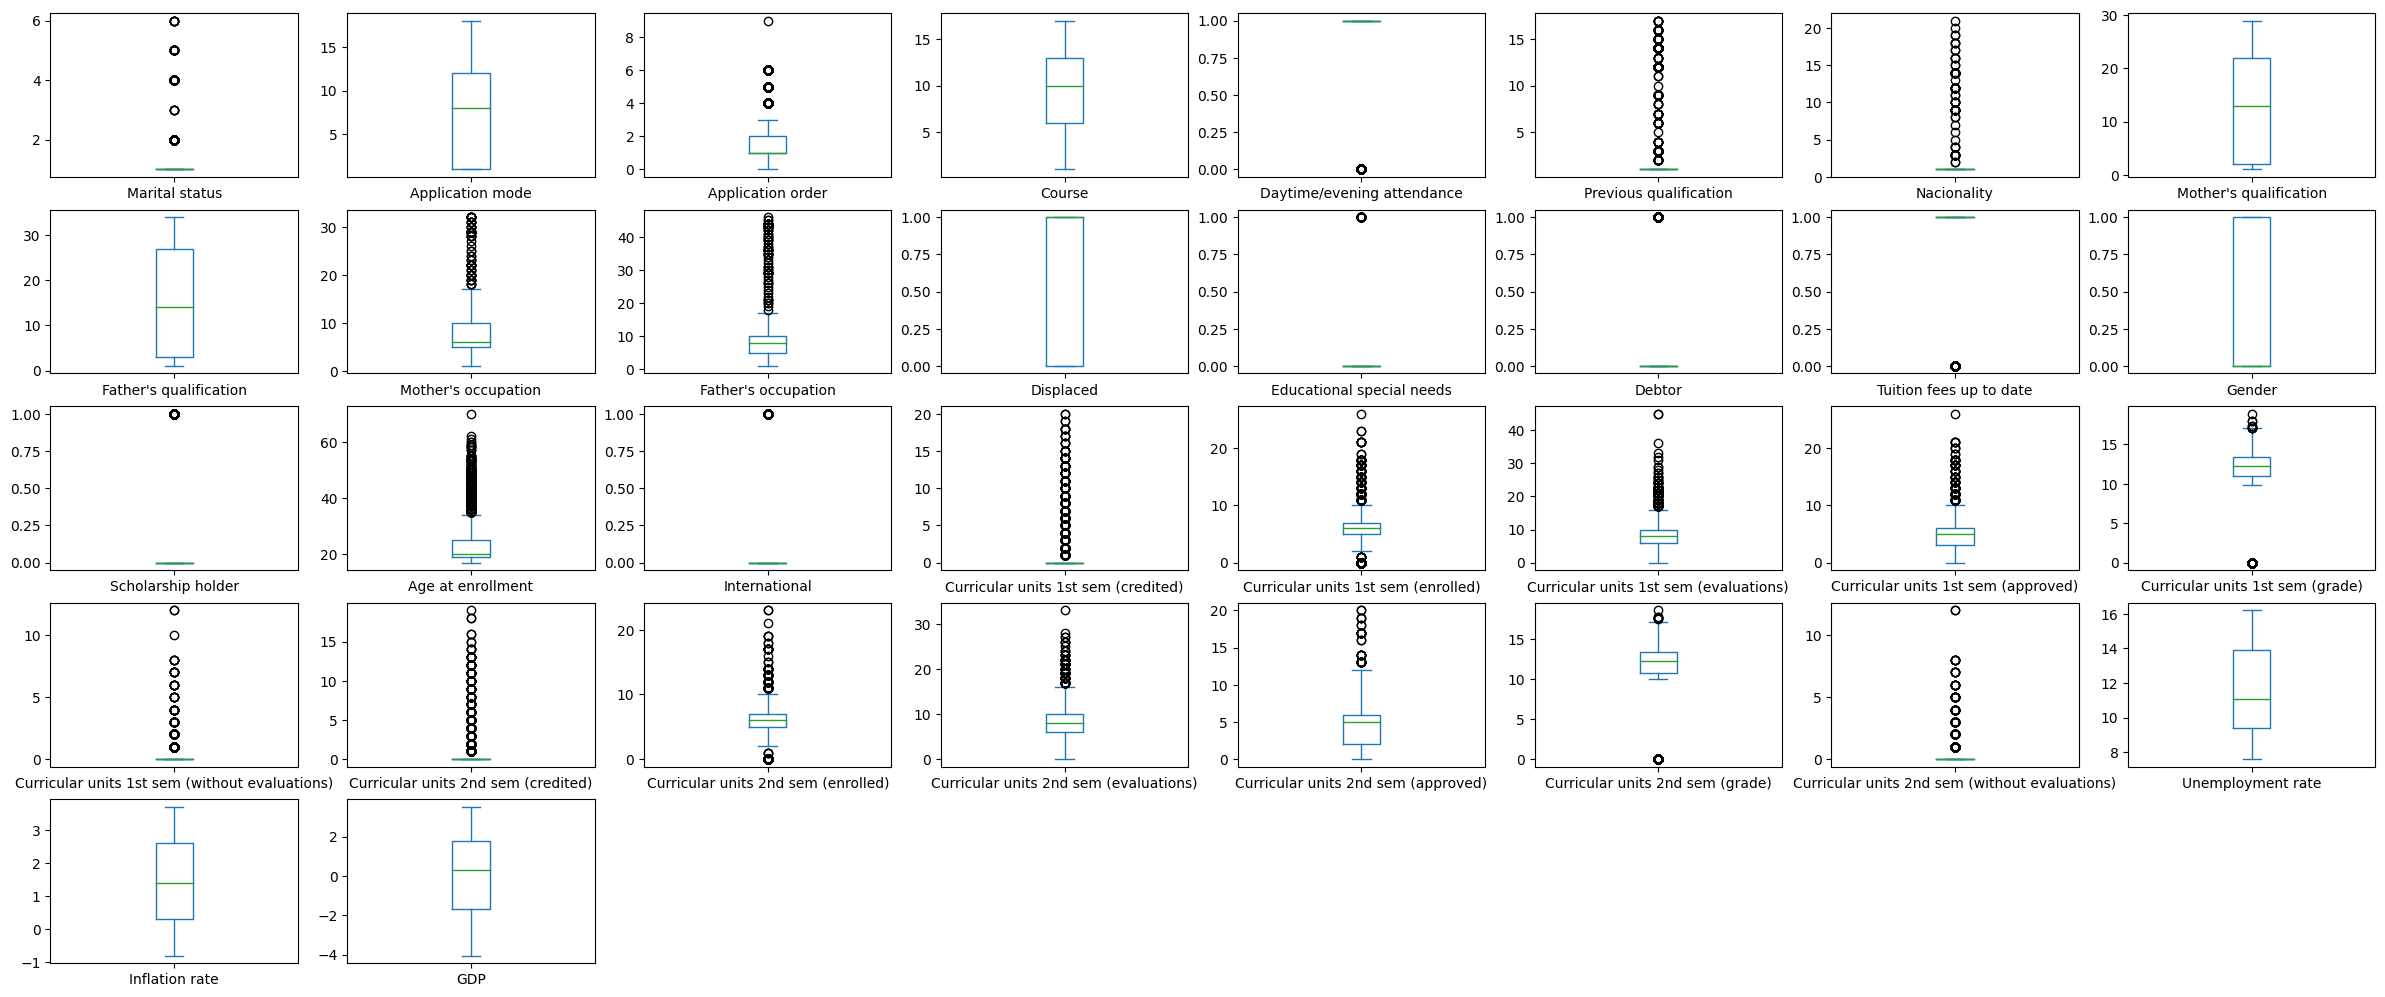

In [ ]:
df.plot(kind='box',subplots=True,layout=(8,8),figsize=(30,20))
plt.show()

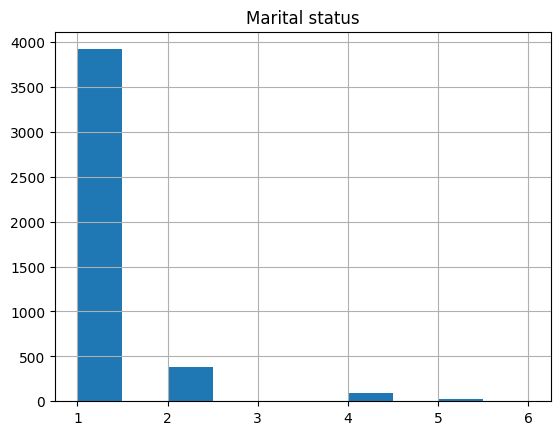

In [ ]:
df.hist('Marital status')
plt.show()

array([[<AxesSubplot: title={'center': 'Marital status'}>,
        <AxesSubplot: title={'center': 'Application mode'}>,
        <AxesSubplot: title={'center': 'Application order'}>,
        <AxesSubplot: title={'center': 'Course'}>,
        <AxesSubplot: title={'center': 'Daytime/evening attendance'}>,
        <AxesSubplot: title={'center': 'Previous qualification'}>],
       [<AxesSubplot: title={'center': 'Nacionality'}>,
        <AxesSubplot: title={'center': "Mother's qualification"}>,
        <AxesSubplot: title={'center': "Father's qualification"}>,
        <AxesSubplot: title={'center': "Mother's occupation"}>,
        <AxesSubplot: title={'center': "Father's occupation"}>,
        <AxesSubplot: title={'center': 'Displaced'}>],
       [<AxesSubplot: title={'center': 'Educational special needs'}>,
        <AxesSubplot: title={'center': 'Debtor'}>,
        <AxesSubplot: title={'center': 'Tuition fees up to date'}>,
        <AxesSubplot: title={'center': 'Gender'}>,
        <AxesSu

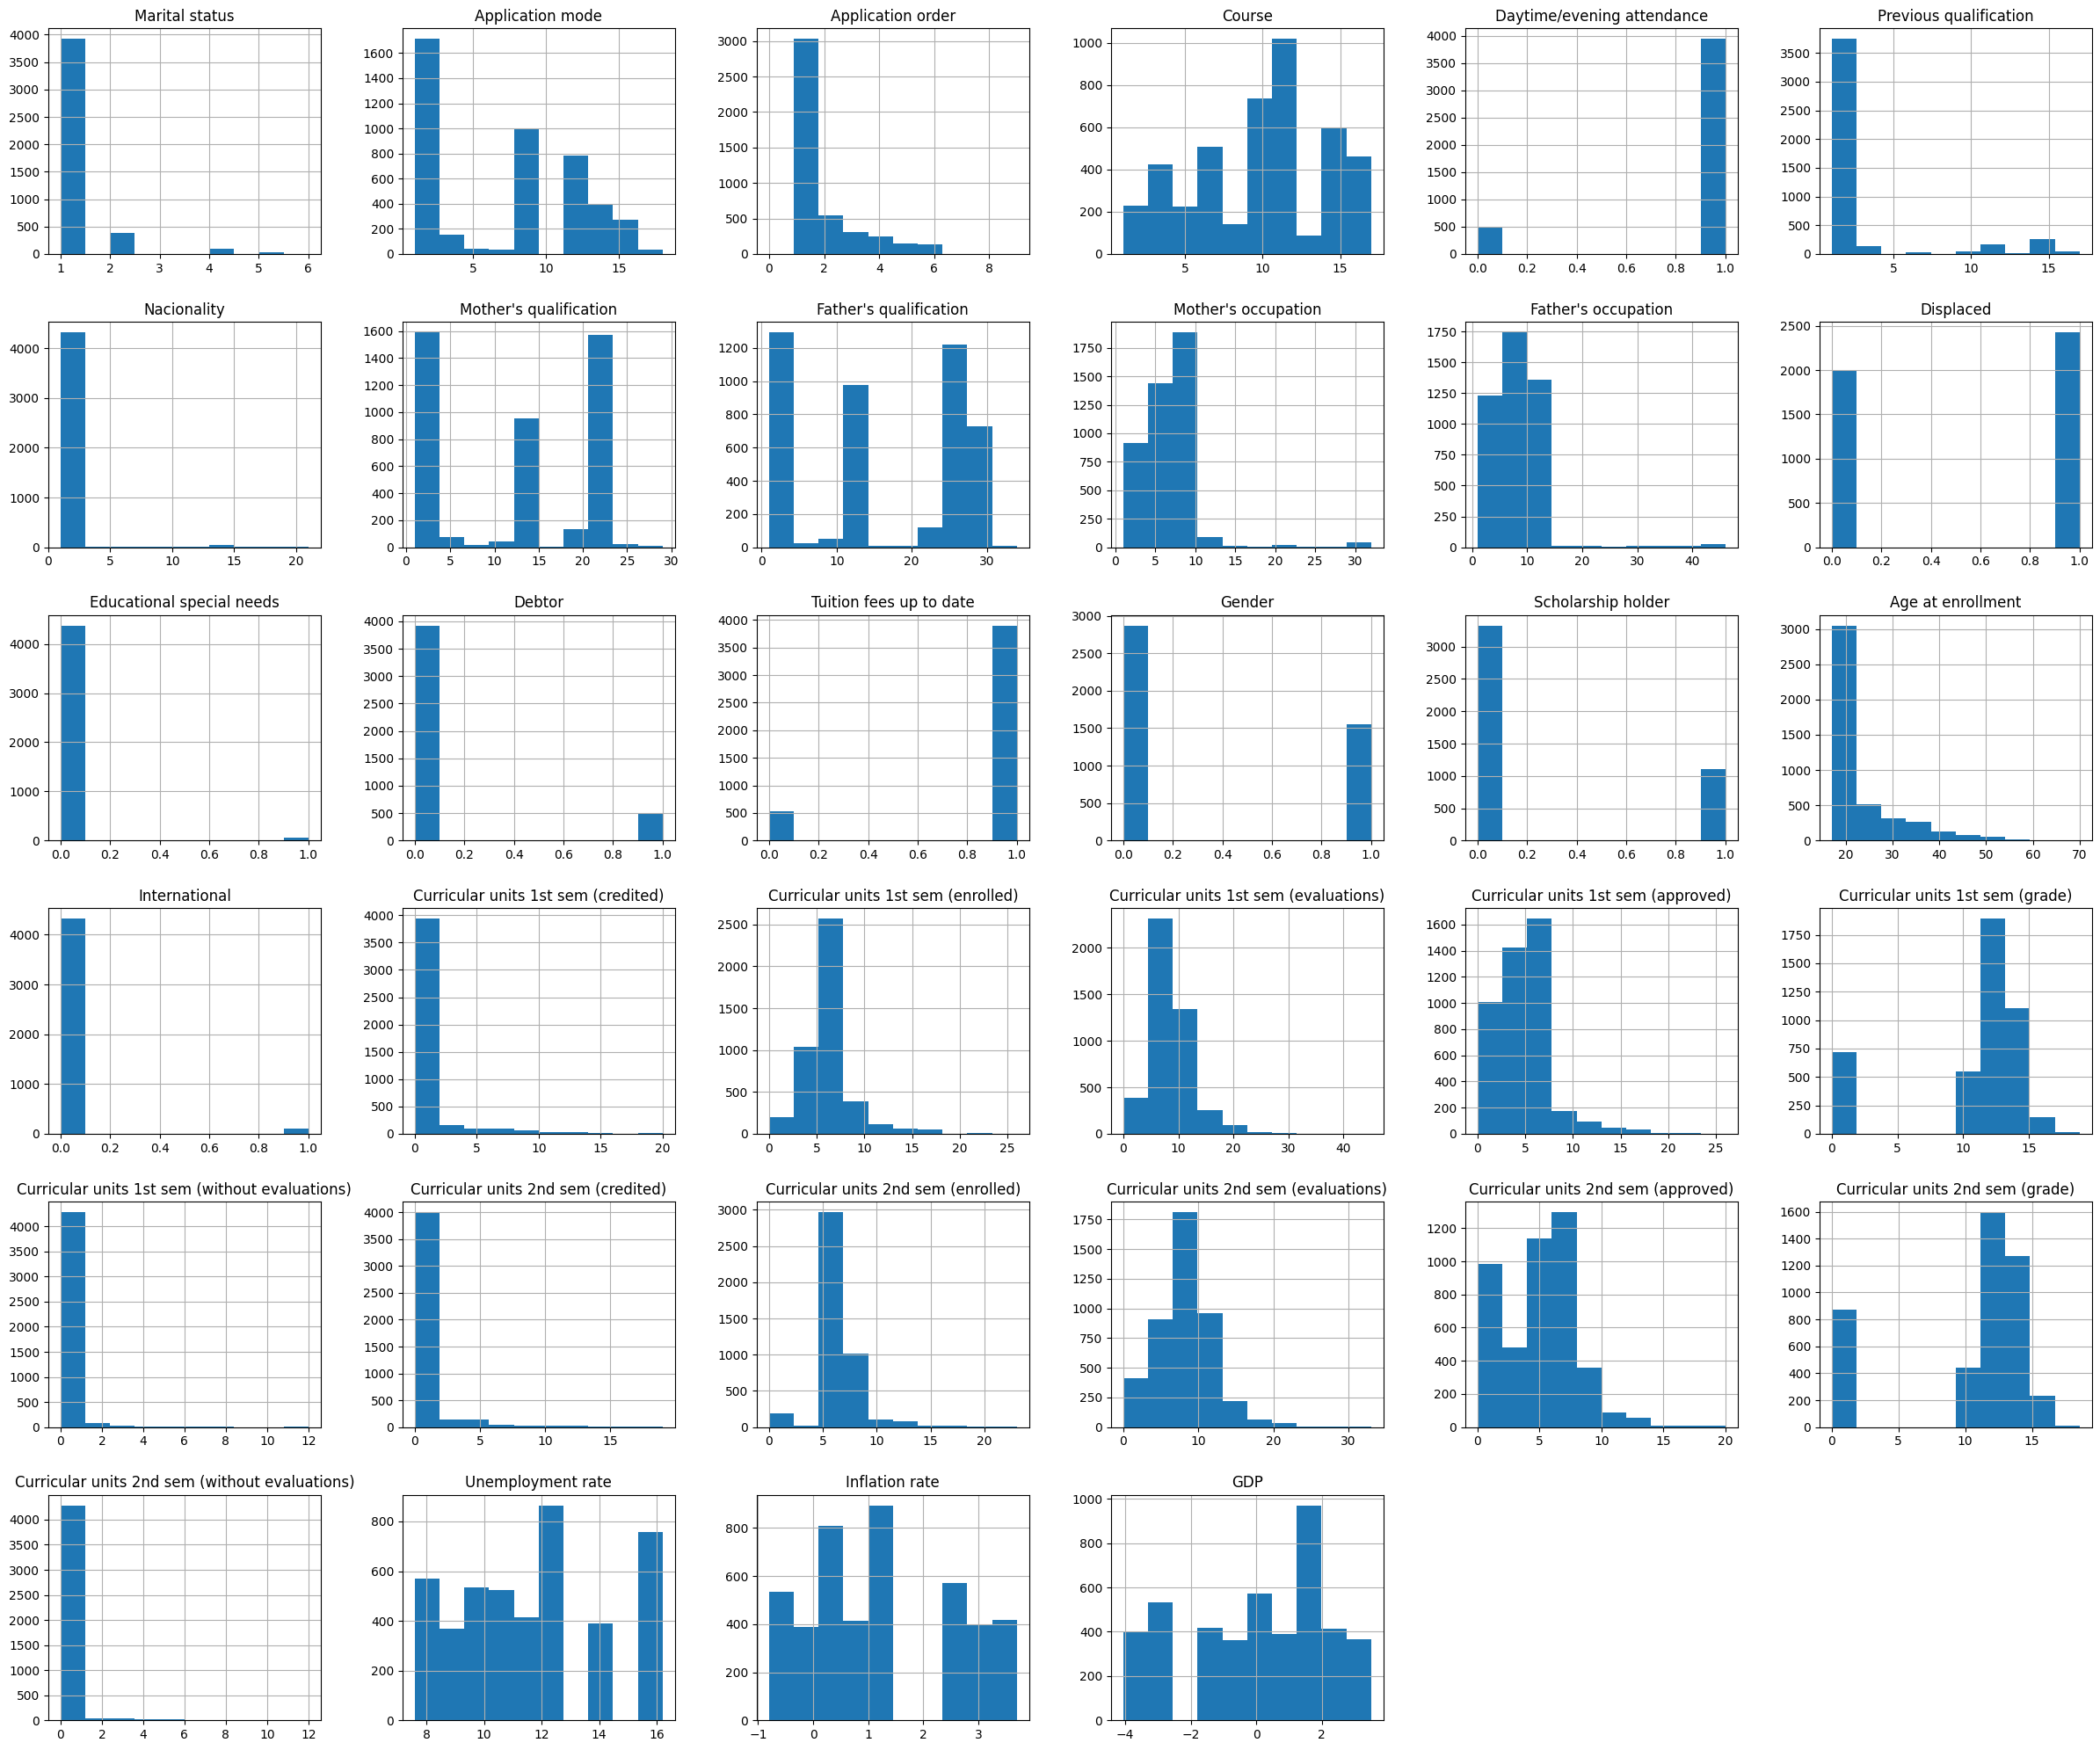

In [ ]:
df.hist(figsize=(30,25))

In [ ]:
# find outlier for Marital Status variable
Marital_status_q1=df['Marital status'].quantile(0.25)
Marital_status_q3=df['Marital status'].quantile(0.75)
Marital_status_iqr=Marital_status_q3 - Marital_status_q1
lower_fence=Marital_status_q1 - (Marital_status_iqr*1.5)
upper_fence=Marital_status_q3 + (Marital_status_iqr*1.5)
print('Marital status outliers are values < {lowerboundary} or > {upperboundary}'.format(lowerboundary=lower_fence, upperboundary=upper_fence))
#df=df[df['Marital status']<Marital_status_q3 + (Marital_status_iqr*1.5)]
df.shape

Marital status outliers are values < 1.0 or > 1.0


(4424, 35)

In [ ]:
# find outlier for Application Order variable
Application_mode_q1=df['Application mode'].quantile(0.25)
Application_mode_q3=df['Application mode'].quantile(0.75)
Application_mode_iqr=Application_mode_q3 - Application_mode_q1
lower_fence=Application_mode_q1 - (Application_mode_iqr*1.5)
upper_fence=Application_mode_q3 + (Application_mode_iqr*1.5)
print('Application Order outliers are values < {lowerboundary} or > {upperboundary}'.format(lowerboundary=lower_fence, upperboundary=upper_fence))

df.shape

Application Order outliers are values < -15.5 or > 28.5


(4424, 35)

In [ ]:
# find outlier for Previous qualification variable
Previous_qualification_q1=df['Previous qualification'].quantile(0.25)
Previous_qualification_q3=df['Previous qualification'].quantile(0.75)
Previous_qualification_iqr=Previous_qualification_q3 - Previous_qualification_q1
lower_fence=Previous_qualification_q1 - (Previous_qualification_iqr*1.5)
upper_fence=Previous_qualification_q3 + (Previous_qualification_iqr*1.5)
print('Application Order outliers are values < {lowerboundary} or > {upperboundary}'.format(lowerboundary=lower_fence, upperboundary=upper_fence))

df.shape

Application Order outliers are values < 1.0 or > 1.0


(4424, 35)

In [ ]:
# find outlier for Nacionality variable
Nacionality_q1=df['Nacionality'].quantile(0.25)
Nacionality_q3=df['Nacionality'].quantile(0.75)
Nacionality_iqr=Nacionality_q3 - Nacionality_q1
lower_fence=Nacionality_q1 - (Nacionality_iqr*1.5)
upper_fence=Nacionality_q3 + (Nacionality_iqr*1.5)
print('Application Order outliers are values < {lowerboundary} or > {upperboundary}'.format(lowerboundary=lower_fence, upperboundary=upper_fence))

df.shape

Application Order outliers are values < 1.0 or > 1.0


(4424, 35)

In [ ]:
# find outlier for Mother's occupation variable
Mother_occupation_q1=df['Mother's occupation'].quantile(0.25)
Mother_occupation_q3=df['Mother's occupation'].quantile(0.75)
Mother_occupation_iqr=Mother_occupation_q3 - Mother_occupation_q1
lower_fence=Mother_occupation_q1 - (Mother_occupation_iqr*1.5)
upper_fence=Mother_occupation_q3 + (Mother_occupation_iqr*1.5)
print('Application Order outliers are values < {lowerboundary} or > {upperboundary}'.format(lowerboundary=lower_fence, upperboundary=upper_fence))

df.shape

SyntaxError: invalid syntax (1856086345.py, line 2)

In [ ]:
# find outlier for Father's occupation variable
Father_occupation_q1=df['Father's occupation'].quantile(0.25)
Father_occupation_q3=df['Father's occupation'].quantile(0.75)
Father_occupation_iqr=Father_occupation_q3 - Father_occupation_q1
lower_fence=Father_occupation_q1 - (Father_occupation_iqr*1.5)
upper_fence=Father_occupation_q3 + (Father_occupation_iqr*1.5)
print('Application Order outliers are values < {lowerboundary} or > {upperboundary}'.format(lowerboundary=lower_fence, upperboundary=upper_fence))

df.shape

In [ ]:
# find outlier for Age at enrollment variable
Age_at_enrollment_q1=df['Age at enrollment'].quantile(0.25)
Age_at_enrollment_q3=df['Age at enrollment'].quantile(0.75)
Age_at_enrollment_iqr=Age_at_enrollment_q3 - Age_at_enrollment_q1
lower_fence=Age_at_enrollment_q1 - (Age_at_enrollment_iqr*1.5)
upper_fence=Age_at_enrollment_q3 + (Age_at_enrollment_iqr*1.5)
print('Application Order outliers are values < {lowerboundary} or > {upperboundary}'.format(lowerboundary=lower_fence, upperboundary=upper_fence))

df.shape

Application Order outliers are values < 10.0 or > 34.0


(4424, 35)

In [ ]:
# find outlier for Curricular units 1st sem (credited) variable
Curricular_1st_sem_q1=df['Curricular units 1st sem (credited)'].quantile(0.25)
Curricular_1st_sem_q3=df['Curricular units 1st sem (credited)'].quantile(0.75)
Curricular_1st_sem_iqr=Curricular_1st_sem_q3 - Curricular_1st_sem_q1
lower_fence=Curricular_1st_sem_q1 - (Curricular_1st_sem_iqr*1.5)
upper_fence=Curricular_1st_sem_q3 + (Curricular_1st_sem_iqr*1.5)
print('Application Order outliers are values < {lowerboundary} or > {upperboundary}'.format(lowerboundary=lower_fence, upperboundary=upper_fence))

df.shape

Application Order outliers are values < 0.0 or > 0.0


(4424, 35)

In [ ]:
# find outlier for Curricular units 1st sem (enrolled) variable
Curricular_1st_sem_q1=df['Curricular units 1st sem (enrolled)'].quantile(0.25)
Curricular_1st_sem_q3=df['Curricular units 1st sem (enrolled)'].quantile(0.75)
Curricular_1st_sem_iqr=Curricular_1st_sem_q3 - Curricular_1st_sem_q1
lower_fence=Curricular_1st_sem_q1 - (Curricular_1st_sem_iqr*1.5)
upper_fence=Curricular_1st_sem_q3 + (Curricular_1st_sem_iqr*1.5)
print('Application Order outliers are values < {lowerboundary} or > {upperboundary}'.format(lowerboundary=lower_fence, upperboundary=upper_fence))

df.shape

Application Order outliers are values < 2.0 or > 10.0


(4424, 35)

In [ ]:
# find outlier for Curricular units 1st sem (evaluations) variable
Curricular_1st_sem_q1=df['Curricular units 1st sem (evaluations)'].quantile(0.25)
Curricular_1st_sem_q3=df['Curricular units 1st sem (evaluations)'].quantile(0.75)
Curricular_1st_sem_iqr=Curricular_1st_sem_q3 - Curricular_1st_sem_q1
lower_fence=Curricular_1st_sem_q1 - (Curricular_1st_sem_iqr*1.5)
upper_fence=Curricular_1st_sem_q3 + (Curricular_1st_sem_iqr*1.5)
print('Application Order outliers are values < {lowerboundary} or > {upperboundary}'.format(lowerboundary=lower_fence, upperboundary=upper_fence))

df.shape

Application Order outliers are values < 0.0 or > 16.0


(4424, 35)

In [ ]:
# find outlier for Curricular units 1st sem (approved) variable
Curricular_1st_sem_q1=df['Curricular units 1st sem (approved)'].quantile(0.25)
Curricular_1st_sem_q3=df['Curricular units 1st sem (approved)'].quantile(0.75)
Curricular_1st_sem_iqr=Curricular_1st_sem_q3 - Curricular_1st_sem_q1
lower_fence=Curricular_1st_sem_q1 - (Curricular_1st_sem_iqr*1.5)
upper_fence=Curricular_1st_sem_q3 + (Curricular_1st_sem_iqr*1.5)
print('Application Order outliers are values < {lowerboundary} or > {upperboundary}'.format(lowerboundary=lower_fence, upperboundary=upper_fence))

df.shape

Application Order outliers are values < -1.5 or > 10.5


(4424, 35)

In [ ]:
# find outlier for Curricular units 1st sem (grade) variable
Curricular_1st_sem_q1=df['Curricular units 1st sem (grade)'].quantile(0.25)
Curricular_1st_sem_q3=df['Curricular units 1st sem (grade)'].quantile(0.75)
Curricular_1st_sem_iqr=Curricular_1st_sem_q3 - Curricular_1st_sem_q1
lower_fence=Curricular_1st_sem_q1 - (Curricular_1st_sem_iqr*1.5)
upper_fence=Curricular_1st_sem_q3 + (Curricular_1st_sem_iqr*1.5)
print('Application Order outliers are values < {lowerboundary} or > {upperboundary}'.format(lowerboundary=lower_fence, upperboundary=upper_fence))

df.shape

Application Order outliers are values < 7.3999999999999995 or > 17.0


(4424, 35)

In [ ]:
# find outlier for Curricular units 1st sem (without evaluations) variable
Curricular_1st_sem_q1=df['Curricular units 1st sem (without evaluations)'].quantile(0.25)
Curricular_1st_sem_q3=df['Curricular units 1st sem (without evaluations)'].quantile(0.75)
Curricular_1st_sem_iqr=Curricular_1st_sem_q3 - Curricular_1st_sem_q1
lower_fence=Curricular_1st_sem_q1 - (Curricular_1st_sem_iqr*1.5)
upper_fence=Curricular_1st_sem_q3 + (Curricular_1st_sem_iqr*1.5)
print('Application Order outliers are values < {lowerboundary} or > {upperboundary}'.format(lowerboundary=lower_fence, upperboundary=upper_fence))

df.shape

Application Order outliers are values < 0.0 or > 0.0


(4424, 35)

In [ ]:
# find outlier for Curricular units 2nd sem (credited) variable
Curricular_2st_sem_q1=df['Curricular units 2nd sem (credited)'].quantile(0.25)
Curricular_2st_sem_q3=df['Curricular units 2nd sem (credited)'].quantile(0.75)
Curricular_2st_sem_iqr=Curricular_2st_sem_q3 - Curricular_2st_sem_q1
lower_fence=Curricular_2st_sem_q1 - (Curricular_2st_sem_iqr*1.5)
upper_fence=Curricular_2st_sem_q3 + (Curricular_2st_sem_iqr*1.5)
print('Application Order outliers are values < {lowerboundary} or > {upperboundary}'.format(lowerboundary=lower_fence, upperboundary=upper_fence))

df.shape

Application Order outliers are values < 0.0 or > 0.0


(4424, 35)

In [ ]:
# find outlier for Curricular units 2nd sem (enrolled) variable
Curricular_2st_sem_q1=df['Curricular units 2nd sem (enrolled)'].quantile(0.25)
Curricular_2st_sem_q3=df['Curricular units 2nd sem (enrolled)'].quantile(0.75)
Curricular_2st_sem_iqr=Curricular_2st_sem_q3 - Curricular_2st_sem_q1
lower_fence=Curricular_2st_sem_q1 - (Curricular_2st_sem_iqr*1.5)
upper_fence=Curricular_2st_sem_q3 + (Curricular_2st_sem_iqr*1.5)
print('Application Order outliers are values < {lowerboundary} or > {upperboundary}'.format(lowerboundary=lower_fence, upperboundary=upper_fence))

df.shape

Application Order outliers are values < 2.0 or > 10.0


(4424, 35)

In [ ]:
# find outlier for Curricular units 2nd sem (evaluations) variable
Curricular_2st_sem_q1=df['Curricular units 2nd sem (evaluations)'].quantile(0.25)
Curricular_2st_sem_q3=df['Curricular units 2nd sem (evaluations)'].quantile(0.75)
Curricular_2st_sem_iqr=Curricular_2st_sem_q3 - Curricular_2st_sem_q1
lower_fence=Curricular_2st_sem_q1 - (Curricular_2st_sem_iqr*1.5)
upper_fence=Curricular_2st_sem_q3 + (Curricular_2st_sem_iqr*1.5)
print('Application Order outliers are values < {lowerboundary} or > {upperboundary}'.format(lowerboundary=lower_fence, upperboundary=upper_fence))

df.shape

Application Order outliers are values < 0.0 or > 16.0


(4424, 35)

In [ ]:
# find outlier for Curricular units 2nd sem (approved) variable
Curricular_2st_sem_q1=df['Curricular units 2nd sem (approved)'].quantile(0.25)
Curricular_2st_sem_q3=df['Curricular units 2nd sem (approved)'].quantile(0.75)
Curricular_2st_sem_iqr=Curricular_2st_sem_q3 - Curricular_2st_sem_q1
lower_fence=Curricular_2st_sem_q1 - (Curricular_2st_sem_iqr*1.5)
upper_fence=Curricular_2st_sem_q3 + (Curricular_2st_sem_iqr*1.5)
print('Application Order outliers are values < {lowerboundary} or > {upperboundary}'.format(lowerboundary=lower_fence, upperboundary=upper_fence))

df.shape

Application Order outliers are values < -4.0 or > 12.0


(4424, 35)

In [ ]:
# find outlier for Curricular units 2nd sem (grade) variable
Curricular_2st_sem_q1=df['Curricular units 2nd sem (grade)'].quantile(0.25)
Curricular_2st_sem_q3=df['Curricular units 2nd sem (grade)'].quantile(0.75)
Curricular_2st_sem_iqr=Curricular_2st_sem_q3 - Curricular_2st_sem_q1
lower_fence=Curricular_2st_sem_q1 - (Curricular_2st_sem_iqr*1.5)
upper_fence=Curricular_2st_sem_q3 + (Curricular_2st_sem_iqr*1.5)
print('Application Order outliers are values < {lowerboundary} or > {upperboundary}'.format(lowerboundary=lower_fence, upperboundary=upper_fence))

df.shape

Application Order outliers are values < 6.874999999999999 or > 17.208333333333336


(4424, 35)

In [ ]:
# find outlier for Curricular units 2nd sem (without evaluations) variable
Curricular_2st_sem_q1=df['Curricular units 2nd sem (without evaluations)'].quantile(0.25)
Curricular_2st_sem_q3=df['Curricular units 2nd sem (without evaluations)'].quantile(0.75)
Curricular_2st_sem_iqr=Curricular_2st_sem_q3 - Curricular_2st_sem_q1
lower_fence=Curricular_2st_sem_q1 - (Curricular_2st_sem_iqr*1.5)
upper_fence=Curricular_2st_sem_q3 + (Curricular_2st_sem_iqr*1.5)
print('Application Order outliers are values < {lowerboundary} or > {upperboundary}'.format(lowerboundary=lower_fence, upperboundary=upper_fence))

df.shape

Application Order outliers are values < 0.0 or > 0.0


(4424, 35)

In [ ]:
x=df.drop(['Target'],axis=1)
y=df['Target']

# split data

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

In [ ]:
x_train.shape,x_test.shape

((3539, 34), (885, 34))

In [ ]:
def max_value(df1, variable, top):
    return np.where(df1[variable]>top, top, df1[variable])

for df1 in [x_train, x_test]:
    df1['Marital status'] = max_value(df1, 'Marital status', 1)
    df1['Application mode'] = max_value(df1,'Application mode', 28.5)
    df1['Previous qualification'] = max_value(df1, 'Previous qualification', 1)
    df1['Nacionality'] = max_value(df1, 'Nacionality', 1)
    df1['Age at enrollment'] = max_value(df1, 'Age at enrollment', 34)
    df1['Curricular units 1st sem (credited)'] = max_value(df1, 'Curricular units 1st sem (credited)', 0)
    df1['Curricular units 1st sem (enrolled)'] = max_value(df1, 'Curricular units 1st sem (enrolled)', 10)
    df1['Curricular units 1st sem (evaluations)'] = max_value(df1,'Curricular units 1st sem (evaluations)', 16)
    df1['Curricular units 1st sem (approved)'] = max_value(df1, 'Curricular units 1st sem (approved)', 10.5)
    df1['Curricular units 1st sem (grade)'] = max_value(df1, 'Curricular units 1st sem (grade)', 17)
    df1['Curricular units 1st sem (without evaluations)'] = max_value(df1, 'Curricular units 1st sem (without evaluations)', 0)
    df1['Curricular units 2nd sem (credited)'] = max_value(df1, 'Curricular units 2nd sem (credited)', 0)
    df1['Curricular units 2nd sem (enrolled)'] = max_value(df1, 'Curricular units 2nd sem (enrolled)', 10)
    df1['Curricular units 2nd sem (evaluations)'] = max_value(df1, 'Curricular units 2nd sem (evaluations)', 16)
    df1['Curricular units 2nd sem (approved)'] = max_value(df1, 'Curricular units 2nd sem (approved)', 12)
    df1['Curricular units 2nd sem (grade)'] = max_value(df1, 'Curricular units 2nd sem (grade)', 17.21)
    df1['Curricular units 2nd sem (without evaluations)'] = max_value(df1, 'Curricular units 2nd sem (without evaluations)', 0)

In [ ]:
x_train.Nacionality.max(),x_test.Nacionality.max()

(1, 1)

# LogisticRegression

In [ ]:
from sklearn.linear_model import LogisticRegression
logestic=LogisticRegression(solver='liblinear')
logestic.fit(x_train,y_train)


LogisticRegression(solver='liblinear')

In [ ]:
y_predict=logestic.predict(x_test)
y_predict

array(['Graduate', 'Dropout', 'Graduate', 'Graduate', 'Dropout',
       'Graduate', 'Graduate', 'Graduate', 'Dropout', 'Graduate',
       'Graduate', 'Dropout', 'Dropout', 'Dropout', 'Enrolled',
       'Graduate', 'Enrolled', 'Dropout', 'Graduate', 'Enrolled',
       'Dropout', 'Graduate', 'Graduate', 'Graduate', 'Graduate',
       'Dropout', 'Graduate', 'Dropout', 'Graduate', 'Graduate',
       'Dropout', 'Dropout', 'Graduate', 'Graduate', 'Graduate',
       'Graduate', 'Graduate', 'Graduate', 'Dropout', 'Dropout',
       'Graduate', 'Dropout', 'Graduate', 'Graduate', 'Graduate',
       'Enrolled', 'Enrolled', 'Graduate', 'Graduate', 'Graduate',
       'Dropout', 'Dropout', 'Graduate', 'Dropout', 'Graduate',
       'Enrolled', 'Graduate', 'Graduate', 'Graduate', 'Graduate',
       'Enrolled', 'Enrolled', 'Graduate', 'Enrolled', 'Enrolled',
       'Graduate', 'Enrolled', 'Graduate', 'Graduate', 'Dropout',
       'Dropout', 'Graduate', 'Enrolled', 'Graduate', 'Dropout',
       'Graduate

In [ ]:
from sklearn.metrics import accuracy_score
print('accuracy: {0:0.4f}'.format(accuracy_score(y_test,y_predict)))

accuracy: 0.7842


# Naive bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB
naive=GaussianNB()
naive.fit(x_train,y_train)

GaussianNB()

In [ ]:
y_predictn=naive.predict(x_test)
y_predictn

array(['Graduate', 'Dropout', 'Graduate', 'Graduate', 'Dropout',
       'Graduate', 'Enrolled', 'Graduate', 'Dropout', 'Graduate',
       'Graduate', 'Dropout', 'Dropout', 'Dropout', 'Enrolled',
       'Graduate', 'Graduate', 'Dropout', 'Graduate', 'Graduate',
       'Dropout', 'Enrolled', 'Enrolled', 'Graduate', 'Graduate',
       'Dropout', 'Graduate', 'Dropout', 'Graduate', 'Enrolled',
       'Dropout', 'Graduate', 'Graduate', 'Graduate', 'Graduate',
       'Graduate', 'Graduate', 'Graduate', 'Dropout', 'Dropout',
       'Graduate', 'Dropout', 'Graduate', 'Graduate', 'Graduate',
       'Dropout', 'Enrolled', 'Graduate', 'Graduate', 'Graduate',
       'Dropout', 'Dropout', 'Graduate', 'Dropout', 'Graduate',
       'Enrolled', 'Enrolled', 'Graduate', 'Dropout', 'Dropout',
       'Graduate', 'Enrolled', 'Graduate', 'Enrolled', 'Enrolled',
       'Graduate', 'Graduate', 'Graduate', 'Graduate', 'Dropout',
       'Dropout', 'Graduate', 'Graduate', 'Graduate', 'Dropout',
       'Graduate',

In [ ]:
print('accuracy: {0:0.4f}'.format(accuracy_score(y_test,y_predictn)))

accuracy: 0.7051


# Decision tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
tree=DecisionTreeClassifier()
tree.fit(x_train,y_train)

DecisionTreeClassifier()

In [ ]:
y_predictT=tree.predict(x_test)
y_predictT

array(['Dropout', 'Dropout', 'Graduate', 'Graduate', 'Enrolled',
       'Enrolled', 'Dropout', 'Graduate', 'Graduate', 'Graduate',
       'Dropout', 'Dropout', 'Dropout', 'Dropout', 'Enrolled', 'Graduate',
       'Enrolled', 'Dropout', 'Graduate', 'Enrolled', 'Dropout',
       'Graduate', 'Dropout', 'Dropout', 'Graduate', 'Dropout',
       'Graduate', 'Dropout', 'Graduate', 'Graduate', 'Enrolled',
       'Graduate', 'Graduate', 'Graduate', 'Graduate', 'Graduate',
       'Graduate', 'Graduate', 'Graduate', 'Dropout', 'Graduate',
       'Dropout', 'Graduate', 'Dropout', 'Graduate', 'Dropout',
       'Enrolled', 'Enrolled', 'Graduate', 'Graduate', 'Dropout',
       'Dropout', 'Dropout', 'Dropout', 'Graduate', 'Dropout', 'Enrolled',
       'Graduate', 'Dropout', 'Graduate', 'Graduate', 'Dropout',
       'Graduate', 'Enrolled', 'Dropout', 'Graduate', 'Dropout',
       'Graduate', 'Graduate', 'Dropout', 'Dropout', 'Graduate',
       'Dropout', 'Enrolled', 'Dropout', 'Graduate', 'Dropout',
  

In [ ]:
print('accuracy: {0:0.4f}'.format(accuracy_score(y_test,y_predictT)))

accuracy: 0.6689


# KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier()
knn.fit(x_train,y_train)

KNeighborsClassifier()

In [ ]:
y_predictKNN=knn.predict(x_test)
y_predictKNN

array(['Graduate', 'Enrolled', 'Graduate', 'Graduate', 'Enrolled',
       'Dropout', 'Dropout', 'Graduate', 'Enrolled', 'Graduate',
       'Enrolled', 'Dropout', 'Graduate', 'Graduate', 'Dropout',
       'Graduate', 'Graduate', 'Dropout', 'Graduate', 'Graduate',
       'Dropout', 'Enrolled', 'Graduate', 'Enrolled', 'Graduate',
       'Graduate', 'Graduate', 'Dropout', 'Graduate', 'Graduate',
       'Enrolled', 'Enrolled', 'Graduate', 'Graduate', 'Graduate',
       'Graduate', 'Graduate', 'Graduate', 'Graduate', 'Dropout',
       'Graduate', 'Dropout', 'Graduate', 'Graduate', 'Graduate',
       'Enrolled', 'Dropout', 'Graduate', 'Dropout', 'Graduate',
       'Dropout', 'Dropout', 'Dropout', 'Dropout', 'Graduate', 'Graduate',
       'Graduate', 'Graduate', 'Dropout', 'Graduate', 'Graduate',
       'Dropout', 'Graduate', 'Graduate', 'Dropout', 'Dropout',
       'Enrolled', 'Graduate', 'Graduate', 'Dropout', 'Dropout',
       'Graduate', 'Graduate', 'Graduate', 'Dropout', 'Graduate',
     

In [ ]:
print('accuracy: {0:0.4f}'.format(accuracy_score(y_test,y_predictKNN)))

accuracy: 0.7006


In [ ]:
from sklearn.svm import SVC
svc=SVC()
svc.fit(x_train,y_train)
y_predictSVC=svc.predict(x_test)
y_predictSVC

array(['Graduate', 'Enrolled', 'Graduate', 'Graduate', 'Enrolled',
       'Graduate', 'Graduate', 'Graduate', 'Dropout', 'Graduate',
       'Graduate', 'Dropout', 'Graduate', 'Graduate', 'Enrolled',
       'Graduate', 'Enrolled', 'Dropout', 'Graduate', 'Enrolled',
       'Dropout', 'Graduate', 'Graduate', 'Graduate', 'Graduate',
       'Enrolled', 'Graduate', 'Dropout', 'Graduate', 'Graduate',
       'Dropout', 'Graduate', 'Graduate', 'Graduate', 'Graduate',
       'Graduate', 'Graduate', 'Graduate', 'Graduate', 'Dropout',
       'Graduate', 'Dropout', 'Graduate', 'Graduate', 'Graduate',
       'Dropout', 'Enrolled', 'Graduate', 'Graduate', 'Graduate',
       'Dropout', 'Dropout', 'Enrolled', 'Dropout', 'Graduate',
       'Enrolled', 'Graduate', 'Graduate', 'Graduate', 'Graduate',
       'Enrolled', 'Enrolled', 'Graduate', 'Enrolled', 'Dropout',
       'Graduate', 'Dropout', 'Graduate', 'Graduate', 'Dropout',
       'Dropout', 'Graduate', 'Dropout', 'Graduate', 'Dropout',
       'Gradu

In [ ]:
print('accuracy: {0:0.4f}'.format(accuracy_score(y_test,y_predictSVC)))

accuracy: 0.7559


In [ ]:
# TypeError: string indices must be integers
#Marital_status='Marital status'
#Application_mode='Application mode'
#Previous_qualification='Previous qualification'
#Nacionality='Nacionality'
#Age_enrollment='Age at enrollment'
#Curricular_1st_sem_credited='Curricular units 1st sem (credited)'
#Curricular_1st_sem_enrolled='Curricular units 1st sem (enrolled)'
#Curricular_1st_sem_evaluations='Curricular units 1st sem (evaluations)'
#Curricular_1st_sem_approved='Curricular units 1st sem (approved)'
#Curricular_1st_sem_grade='Curricular units 1st sem (grade)'
#Curricular_1st_sem_without_evaluations='Curricular units 1st sem (without evaluations)'
#Curricular_2nd_sem_credited='Curricular units 2nd sem (credited)'
#Curricular_2nd_sem_enrolled='Curricular units 2nd sem (enrolled)'
#Curricular_2nd_sem_evaluations='Curricular units 2nd sem (evaluations)'
#Curricular_2nd_sem_approved='Curricular units 2nd sem (approved)'
#Curricular_2nd_sem_grade='Curricular units 2nd sem (grade)'
#Curricular_2nd_sem_without_evaluations='Curricular units 2nd sem (without evaluations)'

In [ ]:
#def max_value(df1, variable, top):
#    return np.where(df1[variable]>top, top, df1[variable])

#for df1 in df:
#    df1[Marital_status] = max_value(df1, df1.columns.get_loc(Marital_status), 1)
#    df1[Application-mode] = max_value(df1, Application_mode, 28.5)
#    df1[Previous-qualification] = max_value(df1, Previous_qualification, 1)
#    df1[Nacionality] = max_value(df1, Nacionality, 1)
#    df1[Age_enrollment] = max_value(df1, Age_enrollment, 34)
#    df1[Curricular_1st_sem_credited] = max_value(df1, Curricular_1st_sem_credited, 0)
#    df1[Curricular_1st_sem_enrolled] = max_value(df1, Curricular_1st_sem_enrolled, 10)
#    df1[Curricular_1st_sem_evaluations] = max_value(df1, Curricular_1st_sem_evaluations, 16)
#    df1[Curricular_1st_sem_approved] = max_value(df1, Curricular_1st_sem_approved, 10.5)
#    df1[Curricular_1st_sem_grade] = max_value(df1, Curricular_1st_sem_grade, 17)
#    df1[Curricular_1st_sem_without_evaluations] = max_value(df1, Curricular_1st_sem_without_evaluations, 0)
#    df1[Curricular_2nd_sem_credited] = max_value(df1, Curricular_2nd_sem_credited, 0)
#    df1[Curricular_2nd_sem_enrolled] = max_value(df1, Curricular_2nd_sem_enrolled, 10)
#    df1[Curricular_2nd_sem_evaluations] = max_value(df1, Curricular_2nd_sem_evaluations, 16)
#    df1[Curricular_2nd_sem_approved] = max_value(df1, Curricular_2nd_sem_approved, 12)
#    df1[Curricular_2nd_sem_grade] = max_value(df1, Curricular_2nd_sem_grade, 17.21)
#    df1[Curricular_2nd_sem_without_evaluations] = max_value(df1, Curricular_2nd_sem_without_evaluations, 0)

AttributeError: 'str' object has no attribute 'columns'